In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('energies.csv',index_col=0)

In [7]:
df

,Method,Energy,Name,Basis Set
0,HF,-74.960552,water,STO-3G
1,CASCI,-75.009479,water,STO-3G
2,SCI,-75.009478,water,STO-3G
0,HF,-55.454318,ammonia,STO-3G
1,CASCI,-55.519929,ammonia,STO-3G
...,...,...,...,...
1,SCI,-191.953772,GDB04_33,aug-cc-pVDZ
0,HF,-215.949690,GDB04_65,aug-cc-pVDZ
1,SCI,-215.950412,GDB04_65,aug-cc-pVDZ
0,HF,-336.812790,GDB04_5,aug-cc-pVDZ


In [8]:
diffdf = []
for basis in df['Basis Set'].unique():
    for molecule in df['Name'].unique():
        subset = df[(df['Basis Set'] == basis) & (df['Name'] == molecule)]
        subset.loc[:, 'Energy'] = subset.loc[:, 'Energy'].values - subset.loc[subset['Method'] == 'SCI', 'Energy'].values
        diffdf.append(subset)

diffdf = pd.concat(diffdf)        

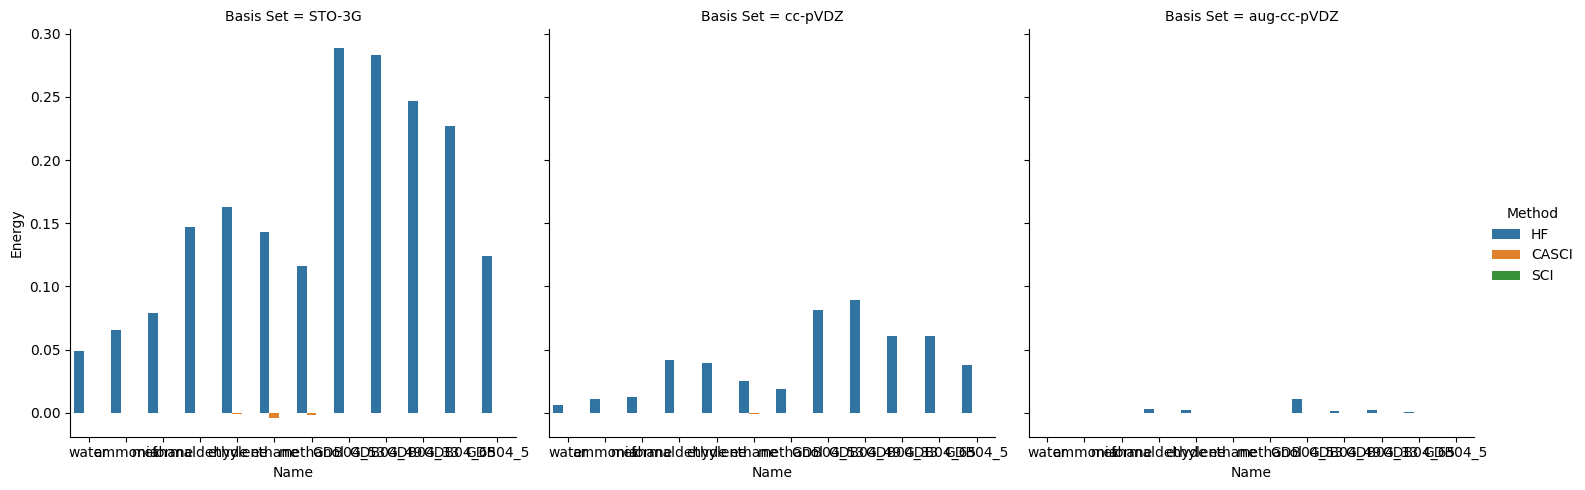

In [10]:
sns.catplot(diffdf,x='Name',y='Energy',hue='Method',col='Basis Set',kind='bar')